# Deutschlandkurier
Load Deutschlandkurier CSV files and create a DataFrame named `df`.


In [1]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Deutschlandkurier"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()


Loaded 1977 rows from 222 file(s) in /Users/katinkakurz/projects/Thesis/data/raw/Alternative Medien/Deutschlandkurier


,id,title,teaser,categories,lastModified,created,publishedAt,authors,url,article_text,source,source_file
0,92655,Autokrise: Auch BMW-Gewinne brechen massiv ein!,Die Horrormeldungen aus der Automobilbranche r...,Wirtschaft,2025-07-31T08:50:16+00:00,2025-07-31T08:50:16+00:00,2025-07-31T08:50:16+00:00,NaN,https://deutschlandkurier.de/2025/07/autokrise...,Die Horrormeldungen aus der Automobilbranche r...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
1,92658,Verfassungsrichter: Top-Staatsrechtler Rupert ...,Vor dem Hintergrund des aktuellen Streits um d...,Politik,2025-07-31T11:59:26+00:00,2025-07-31T09:16:48+00:00,2025-07-31T09:16:48+00:00,NaN,https://deutschlandkurier.de/2025/07/verfassun...,Vor dem Hintergrund des aktuellen Streits um d...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
2,92666,„Nazi-Codes!“ Woker Aufstand im Netz gegen Syd...,Die US-amerikanische Schauspielerin Sydney Swe...,Ausland,2025-07-31T11:09:19+00:00,2025-07-31T11:09:19+00:00,2025-07-31T11:09:19+00:00,NaN,https://deutschlandkurier.de/2025/07/nazi-code...,Die US-amerikanische Schauspielerin Sydney Swe...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
3,92669,SPD löscht Wut-Attacke auf Union aus Online-Ka...,In einer Online-Kampagne hat die SPD ihren Koa...,Politik,2025-07-31T11:46:15+00:00,2025-07-31T11:46:15+00:00,2025-07-31T11:46:15+00:00,NaN,https://deutschlandkurier.de/2025/07/spd-loesc...,In einer Online-Kampagne hat die SPD ihren Koa...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
4,92672,Bürgermeister von Hiddensee schreibt Alarm-Bri...,Der Bürgermeister der 1.000 Einwohner zählende...,Politik,2025-07-31T11:48:25+00:00,2025-07-31T11:48:25+00:00,2025-07-31T11:48:25+00:00,NaN,https://deutschlandkurier.de/2025/07/buergerme...,Der Bürgermeister der 1.000 Einwohner zählende...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv


In [2]:
df_cleaned = df[['title', 'categories', 'created', 'article_text', 'url', 'source']].copy()
df_cleaned.columns = ['Title', 'categories', 'Date', 'Text', 'URL', 'source']

In [3]:
# Check duplicates and NaNs in Title/Text columns using df_cleaned
title_col = "Title" if "Title" in df_cleaned.columns else "title" if "title" in df_cleaned.columns else None
text_col = "Text" if "Text" in df_cleaned.columns else "text" if "text" in df_cleaned.columns else "article_text" if "article_text" in df_cleaned.columns else None

if title_col is None or text_col is None:
    raise KeyError(f"Could not find title/text columns in df_cleaned. Available columns: {list(df_cleaned.columns)}")

check_cols = [title_col, text_col]

# NaN counts
nan_counts = df_cleaned[check_cols].isna().sum()

# Duplicate counts (excluding NaN values)
dup_title_count = df_cleaned[title_col].dropna().duplicated().sum()
dup_text_count = df_cleaned[text_col].dropna().duplicated().sum()
dup_title_text_pair_count = df_cleaned[check_cols].dropna().duplicated().sum()

print("NaN counts:")
print(nan_counts)
print("\nDuplicate counts:")
print(f"Duplicate {title_col}: {dup_title_count}")
print(f"Duplicate {text_col}: {dup_text_count}")
print(f"Duplicate ({title_col}, {text_col}) pairs: {dup_title_text_pair_count}")

# Optional: preview duplicate rows by title+text
duplicate_rows = df_cleaned[df_cleaned.duplicated(subset=check_cols, keep=False)].sort_values(check_cols)
print(f"\nRows involved in duplicated ({title_col}, {text_col}) pairs: {len(duplicate_rows)}")
duplicate_rows.head(10)

NaN counts:
Title     38
Text     154
dtype: int64

Duplicate counts:
Duplicate Title: 7
Duplicate Text: 9
Duplicate (Title, Text) pairs: 1

Rows involved in duplicated (Title, Text) pairs: 40


,Title,categories,Date,Text,URL,source
1947,Gewinner – Verlierer der Woche,Gewinner und Verlierer der Woche,2026-03-07T09:08:02+00:00,Gewinner der Woche\n\nDie 10. Klasse des Oster...,https://deutschlandkurier.de/2026/03/gewinner-...,Deutschlandkurier
1958,Gewinner – Verlierer der Woche,Mehr,2026-03-07T20:26:52+00:00,Gewinner der Woche\n\nDie 10. Klasse des Oster...,https://deutschlandkurier.de/2026/03/gewinner-...,Deutschlandkurier
110,NaN,AfD,2025-08-13T10:39:03+00:00,NaN,https://deutschlandkurier.de/2025/08/93109/,Deutschlandkurier
111,NaN,AfD,2025-08-13T11:55:59+00:00,NaN,https://deutschlandkurier.de/2025/08/93114/,Deutschlandkurier
113,NaN,AfD,2025-08-13T12:20:10+00:00,NaN,https://deutschlandkurier.de/2025/08/93125/,Deutschlandkurier
114,NaN,AfD,2025-08-13T13:17:50+00:00,NaN,https://deutschlandkurier.de/2025/08/93128/,Deutschlandkurier
122,NaN,AfD,2025-08-14T10:21:14+00:00,NaN,https://deutschlandkurier.de/2025/08/93159/,Deutschlandkurier
213,NaN,AfD,2025-08-24T12:10:40+00:00,NaN,https://deutschlandkurier.de/2025/08/93532/,Deutschlandkurier
228,NaN,AfD,2025-08-25T14:17:49+00:00,NaN,https://deutschlandkurier.de/2025/08/93589/,Deutschlandkurier
244,NaN,AfD,2025-08-27T09:17:07+00:00,NaN,https://deutschlandkurier.de/2025/08/93652/,Deutschlandkurier


In [4]:
# Remove rows with NaN in text column and drop duplicate title+text pairs (on df_cleaned only)
rows_before = len(df_cleaned)

nan_text_removed = df_cleaned[text_col].isna().sum()
df_cleaned = df_cleaned[df_cleaned[text_col].notna()].copy()

dup_removed = df_cleaned.duplicated(subset=check_cols, keep="first").sum()
df_cleaned = df_cleaned.drop_duplicates(subset=check_cols, keep="first").copy()

rows_after = len(df_cleaned)
print(f"Removed {nan_text_removed} rows with NaN in '{text_col}'.")
print(f"Removed {dup_removed} duplicate rows based on {check_cols}.")
print(f"Rows before: {rows_before} | Rows after: {rows_after}")


Removed 154 rows with NaN in 'Text'.
Removed 1 duplicate rows based on ['Title', 'Text'].
Rows before: 1977 | Rows after: 1822


In [5]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1822 entries, 0 to 1976
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       1822 non-null   object
 1   categories  1822 non-null   object
 2   Date        1822 non-null   object
 3   Text        1822 non-null   object
 4   URL         1822 non-null   object
 5   source      1822 non-null   str   
dtypes: object(5), str(1)
memory usage: 99.6+ KB


In [6]:
# Convert Date to datetime dtype
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], errors="coerce")



In [7]:
df_cleaned['Date'].min()

Timestamp('2025-07-31 08:50:16+0000', tz='UTC')

In [8]:
# keep Date as real datetime
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], utc=True, errors="coerce")

# optional: remove timezone + keep only date (00:00:00 time)
df_cleaned["Date"] = df_cleaned["Date"].dt.tz_convert(None).dt.normalize()

# correct chronological min/max
print(df_cleaned["Date"].min(), df_cleaned["Date"].max())


2025-07-31 00:00:00 2026-03-09 00:00:00


In [9]:
# df_cleaned["Date"] = (
#     pd.to_datetime(df_cleaned["Date"], utc=True, errors="coerce")
#       .dt.tz_convert(None)
#       .dt.normalize()
# )

# print(df_cleaned["Date"].dtype)   # datetime64[ns]


In [10]:
df_cleaned["Date"] = (
    pd.to_datetime(df_cleaned["Date"], utc=True, errors="coerce")
      .dt.tz_convert(None)
      .dt.date
)


In [11]:
print(df_cleaned["Date"].min(), df_cleaned["Date"].max())

2025-07-31 2026-03-09


In [12]:
# Filter df_cleaned to 01.08.2025 - 31.01.2026 (inclusive)
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], errors="coerce")
df_cleaned = df_cleaned.loc[
    (df_cleaned["Date"] >= "2025-08-01") & (df_cleaned["Date"] <= "2026-01-31")
].copy()

print(f"Rows after date filter: {len(df_cleaned)}")
print("Date range:", df_cleaned["Date"].min(), "->", df_cleaned["Date"].max())


Rows after date filter: 1484
Date range: 2025-08-01 00:00:00 -> 2026-01-31 00:00:00


In [13]:
df_cleaned["Date"] = (
    pd.to_datetime(df_cleaned["Date"], utc=True, errors="coerce")
      .dt.tz_convert(None)
      .dt.date
)


In [14]:
print(df_cleaned["Date"].min(), df_cleaned["Date"].max())

2025-08-01 2026-01-31


## EDA

In [15]:
# Short EDA prep based on df_cleaned
eda_df = df_cleaned.copy()

if "Text" not in eda_df.columns:
    raise KeyError("Spalte 'Text' nicht gefunden in df_cleaned.")
if "Date" not in eda_df.columns:
    raise KeyError("Spalte 'Date' nicht gefunden in df_cleaned.")

eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")
eda_df["Date"] = eda_df["Date"].dt.strftime("%Y.%m.%d")

eda_df["article_length_words"] = eda_df["Text"].astype("string").str.split().str.len()

eda_df[["Date", "article_length_words"]].head()


,Date,article_length_words
9,2025.08.01,100
10,2025.08.01,110
11,2025.08.01,336
12,2025.08.01,219
13,2025.08.01,47


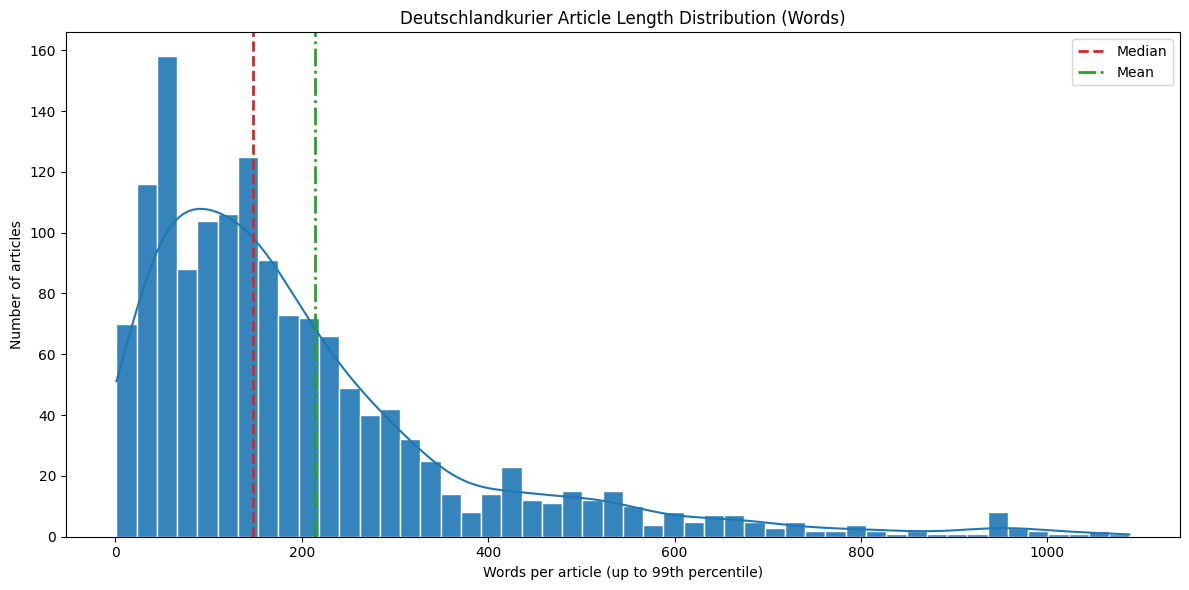

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Deutschlandkurier Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


Save cleaned table for further analysis

In [17]:
# dkurier_clean = df_cleaned[["Date", "Title", "Text", "source"]].copy()
# dkurier_clean.to_csv("dkurier_clean.csv", index=False, encoding="utf-8")

## BERTopic

In [18]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [19]:
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [20]:
from BERTopic.bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)

2 0.9


In [21]:
from pathlib import Path
import sys

# from ".../data preprocessing" -> project root ".../Thesis"
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)


cwd: /Users/katinkakurz/projects/Thesis/data preprocessing
project root added: /Users/katinkakurz/projects/Thesis


In [28]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_cleaned,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="Deutschlandkurier",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-10 18:43:22,881 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

2026-03-10 18:43:30,236 - BERTopic - Embedding - Completed ✓
2026-03-10 18:43:30,236 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 18:43:32,972 - BERTopic - Dimensionality - Completed ✓
2026-03-10 18:43:32,972 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 18:43:32,990 - BERTopic - Cluster - Completed ✓
2026-03-10 18:43:32,992 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 18:43:33,221 - BERTopic - Representation - Completed ✓


In [162]:
topic_info_dkurier = result["topic_info"]
topic_info_dkurier.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,380,-1_euro_eu_weimer_us,"[euro, eu, weimer, us, demokratie, söder, mill...","[Es gibt unzählige Methoden, mit denen eine po..."
1,0,129,0_sachsen_sachsen anhalt_anhalt_siegmund,"[sachsen, sachsen anhalt, anhalt, siegmund, de...",[Im Interview mit der DeutschlandKURIER-Report...
2,1,122,1_faeser_bendels_meinungsfreiheit_david,"[faeser, bendels, meinungsfreiheit, david, dav...",[Der Countdown läuft: Am 14. Januar findet vor...
3,2,113,2_trump_us_ukraine_putin,"[trump, us, ukraine, putin, präsident, selensk...",[US-Präsident Donald Trump und sein russischer...
4,3,92,3_afghanen_migranten_000_asyl,"[afghanen, migranten, 000, asyl, personen, eu,...",[Die Migration als Goldgrube für Asyl-Industri...
5,4,84,4_klima_energiewende_co₂_gas,"[klima, energiewende, co₂, gas, studie, strom,...",[Kurz vor Weihnachten sind die Gasspeicher in ...
6,5,74,5_kanzler_koalition_cdu csu_rentenpaket,"[kanzler, koalition, cdu csu, rentenpaket, sch...",[Gut 48 Stunden vor der für Freitag (5.Dezembe...
7,6,74,6_euro_milliarden_milliarden euro_millionen,"[euro, milliarden, milliarden euro, millionen,...",[Der Haushaltsausschuss des Deutschen Bundesta...
8,7,70,7_merkel_polizei_berliner_opfer,"[merkel, polizei, berliner, opfer, mahnmal, 20...",[Es ist eine spektakuläre frühmorgendliche Akt...
9,8,66,8_polizei_weihnachtsmarkt_festgenommen_syrer,"[polizei, weihnachtsmarkt, festgenommen, syrer...",[Hochsicherheits-Festung Weihnachtsmarkt: Ange...


In [30]:
#  save embedding model
dk_model = result["topic_model"]
dk_model.save(
    "/Users/katinkakurz/projects/Thesis/BERTopic/outputsdk_model",
    serialization="safetensors",   # more robust than pickle
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)
